In [13]:
import re
import matplotlib.pyplot as plt
from collections import Counter

In [14]:
'''Filtered only the Bestiary from https://github.com/fcampelo/EC-Bestiary/blob/master/README.md'''
ec_bestiary_filtered_path = r'ec_bestiary_21_09_2026.md'

In [ ]:
with open(ec_bestiary_filtered_path, "r", encoding="utf-8") as f:
    text = f.read()

years = [int(y) for y in re.findall(r'\((\d{4})\)', text)]
# Counter collection to count elements frequency
counts = Counter(years)

["### A\n- **<u>African Buffalo</u>**: Odili JB, Kahar MNM (2016). “Solving the Traveling Salesman's Problem Using the African Buffalo Optimization.” _Computational Intelligence and Neuroscience_, *2016*, 1-12. doi:[10.1155/2016/1510256](https://doi.org/10.1155/2016/1510256) \n- **<u>Al-Biruni</u>**: M. El-kenawy E, A. Abdelhamid A, Ibrahim A, Mirjalili S, Khodadad N, A. Al duailij M, Ali Alhussan A, Sami Khafaga D (2023). “Al-Biruni Earth Radius (BER) Metaheuristic Search Optimization Algorithm.” _Computer Systems Science and Engineering_, *45*(2), 1917–1934. ISSN 0267-6192, doi:[10.32604/csse.2023.032497](https://doi.org/10.32604/csse.2023.032497) \n- **<u>Algae</u>**: Uymaz SA, Tezel G, Yel E (2015). “Artificial algae algorithm (AAA) for nonlinear global optimization.” _Applied Soft Computing_, *31*, 153-171. doi:[10.1016/j.asoc.2015.03.003](https://doi.org/10.1016/j.asoc.2015.03.003) \n- **<u>Ali Baba And The Forty Thieves</u>**: Braik M, Ryalat MH, Al-Zoubi H (2021). “A novel meta

In [16]:
'''Grouping all elements until 2000 (better plot visualization)'''
grouped = {
    "Até 2000": sum(
        count for year, count in counts.items()
        if year <= 2000
    )
}
'''Appending other groups (after 2001)'''
grouped.update({
    str(year): counts[year]
    for year in sorted(counts)
    if year > 2000
})
labels = list(grouped.keys())
values = list(grouped.values())

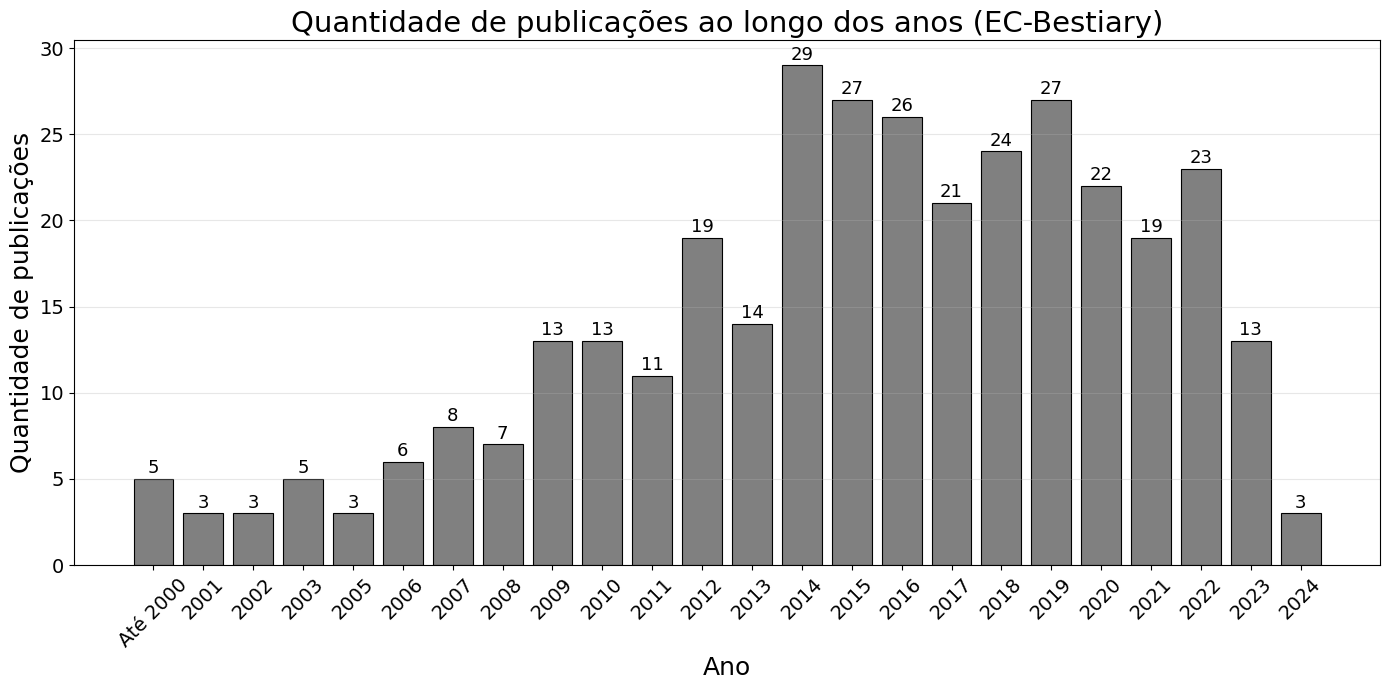

In [17]:
'''Plotting'''
plt.figure(figsize=(14, 7))
bars = plt.bar(
    labels,
    values,
    color='gray',
    edgecolor="black",
    linewidth=0.8
)
plt.title("Quantidade de publicações ao longo dos anos (EC-Bestiary)",fontsize=21)
plt.xlabel("Ano",fontsize=18)
plt.ylabel("Quantidade de publicações",fontsize=18)

plt.xticks(rotation=45,fontsize=14)
plt.yticks(fontsize=14)

# Grade horizontal
plt.grid(axis="y",alpha=0.3)

# Valores sobre cada barra
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(value),
        ha="center",
        va="bottom",
        fontsize=13
    )

plt.tight_layout()
plt.show()